<div style="background:linear-gradient(135deg,#ffffff,#fffdfd);color:#5c1d0c;padding:22px;border-left:6px solid #E24307;border-radius:12px;font-family:'Segoe UI',sans-serif;box-shadow:0px 4px 12px rgba(0,0,0,0.15);">
  <div style="display:flex;align-items:center;gap:12px;">
    <img src="data/logo-swift.png" alt="Logo Swift" style="height:45px;">
    <h2 style="color:#E24307;margin:0;letter-spacing:1px;font-size:24px;">Definição da Análise de Sentimento</h2>
  </div>
  <hr style="border:0;border-top:1px solid #f4b39a;margin:15px 0;">
  <p style="margin:8px 0;"><b style="color:#a12d00;">Membros:</b>
    <span style="color:#5f3a2d;font-size:13px;">Bruna Carvalho Cardoso | Giovanne Antony Bahia Torquato | Kaique Moreira Arantes De Souza | Letícia Nascimento da Silva | Sofia Bonini Pinto</span>
  </p>
  <p style="margin:8px 0;"><b style="color:#a12d00;">Data Entrega:</b>
    <span style="color:#5f3a2d;font-size:13px;">09/06/2026</span>
  </p>
</div>

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">0. Importações e Configurações</h2>
</div>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Paleta de cores Swift
PALETTE  = {'promotor': '#E24307', 'neutro': '#f39c12', 'detrator': '#5c1d0c'}
CORES    = [PALETTE['promotor'], PALETTE['neutro'], PALETTE['detrator']]
ORDER    = ['promotor', 'neutro', 'detrator']

print('✅ Ambiente configurado.')

✅ Ambiente configurado.


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">1. Carregamento e Preparação dos Dados</h2>
</div>

In [2]:
caminho_arquivo = 'data/base_final.csv'
df_raw = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')

print(f'Shape original: {df_raw.shape}')
df_raw.head(3)

Shape original: (239898, 30)


,mes_ano,classificacao,data_avaliacao,centro_nv2,qtd_clientes,comentario,flag,ano,mes,trimestre,...,transacoes,regiao,municipio,uf,nps_cat,nps_score,n_promotores,n_neutros,n_detratores,tem_comentario_int
0,2025-01-01,promotor,2025-01-01,L5001-RIBEIRAO PRETO (0217),6,-,regular,2025,1,1,...,9738.0,Interior,RIBEIRÃO PRETO,SP,1,100,6,0,0,0
1,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,Bastante falta. De produto. Talvez pela data. ...,regular,2025,1,1,...,9738.0,Interior,RIBEIRÃO PRETO,SP,0,0,0,1,0,1
2,2025-01-01,neutro,2025-01-02,L5001-RIBEIRAO PRETO (0217),1,"Estrutura excelente, mas, os peços deveriam se...",regular,2025,1,1,...,9738.0,Interior,RIBEIRÃO PRETO,SP,0,0,0,1,0,1


In [3]:
df = df_raw.copy()

# Garante tipos corretos
df['classificacao']    = df['classificacao'].str.lower().str.strip()
df['comentario_limpo'] = df['comentario_limpo'].astype(str)
df['comentario']       = df['comentario'].astype(str)

# Subconjunto com comentário
df_com = df[df['tem_comentario'] == True].copy()

print(f'Total de registros  : {len(df):,}')
print(f'Com comentário      : {len(df_com):,}  ({len(df_com)/len(df)*100:.1f}%)')
print(f'Lojas únicas        : {df["centro_nv2"].nunique()}')

Total de registros  : 239,898
Com comentário      : 128,275  (53.5%)
Lojas únicas        : 228


<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.1 — Granularidade dos Sentimentos</h2>
</div>

**Perguntas respondidas:**
- Qual a proporção de promotores, neutros e detratores na base?
- O desbalanceamento da base justifica uma abordagem ternária?
- Quantas classes de sentimento são viáveis dado o volume de cada grupo?

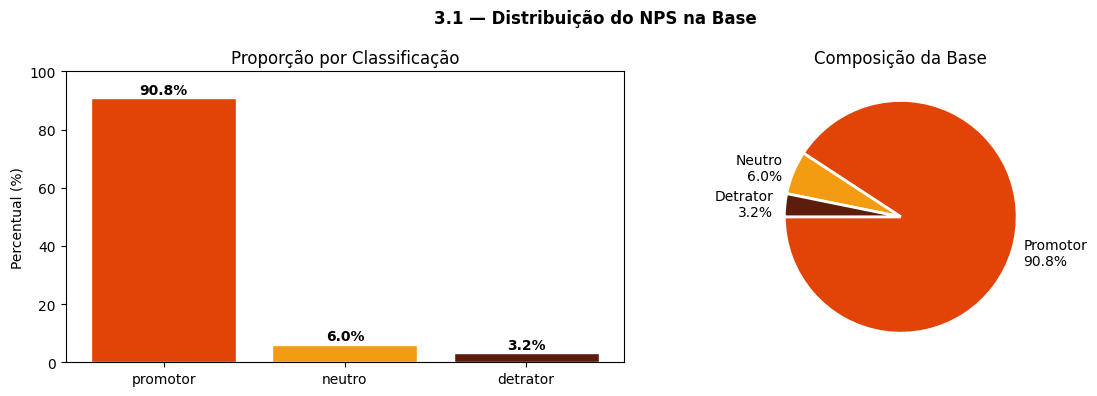

Promotores : 90.8%
Neutros    : 6.0%
Detratores : 3.2%


In [17]:
# Distribuição global das classificações
contagem = (
    df.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)
pct = contagem / contagem.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — Distribuição do NPS na Base', fontweight='bold')

# Gráfico de barras
bars = axes[0].bar(ORDER, pct, color=CORES, edgecolor='white')
for bar, valor in zip(bars, pct):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{valor:.1f}%',
        ha='center', va='bottom', fontweight='bold'
    )
axes[0].set_ylabel('Percentual (%)')
axes[0].set_title('Proporção por Classificação')
axes[0].set_ylim(0, 100)

# Gráfico de pizza
axes[1].pie(
    pct,
    labels=[f'{c.capitalize()}\n{v:.1f}%' for c, v in zip(ORDER, pct)],
    colors=CORES,
    startangle=180,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Composição da Base')

plt.tight_layout()
plt.show()

print(f'Promotores : {pct["promotor"]:.1f}%')
print(f'Neutros    : {pct["neutro"]:.1f}%')
print(f'Detratores : {pct["detrator"]:.1f}%')

In [5]:
# Volume absoluto por classe — viabilidade de treino
vol_com = (
    df_com.groupby('classificacao')['qtd_clientes']
    .sum()
    .reindex(ORDER)
    .fillna(0)
)

print('Volume de comentários por classe:')
for classe, vol in vol_com.items():
    print(f'  {classe:<12}: {int(vol):>8,} avaliações')

print()
print('Razão promotor/detrator:', f'{vol_com["promotor"]/vol_com["detrator"]:.0f}x')
print('Razão promotor/neutro  :', f'{vol_com["promotor"]/vol_com["neutro"]:.0f}x')

Volume de comentários por classe:
  promotor    :  100,456 avaliações
  neutro      :   15,935 avaliações
  detrator    :   11,993 avaliações

Razão promotor/detrator: 8x
Razão promotor/neutro  : 6x


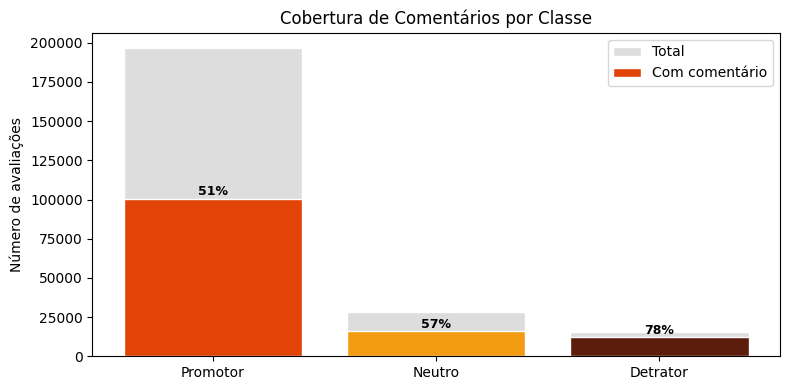

In [6]:
# Distribuição de comentários com e sem texto por classe
cobertura = (
    df.groupby('classificacao')
    .agg(
        total=('comentario', 'size'),
        com_comentario=('tem_comentario', 'sum')
    )
    .reindex(ORDER)
)
cobertura['pct'] = cobertura['com_comentario'] / cobertura['total'] * 100

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ORDER))
bars_total = ax.bar(x, cobertura['total'], color='#ddd', label='Total', edgecolor='white')
bars_com   = ax.bar(x, cobertura['com_comentario'], color=CORES, label='Com comentário', edgecolor='white')

for bar, pct_val in zip(bars_com, cobertura['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{pct_val:.0f}%',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_xticks(list(x))
ax.set_xticklabels([c.capitalize() for c in ORDER])
ax.set_ylabel('Número de avaliações')
ax.set_title('Cobertura de Comentários por Classe')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Conclusão acionável - 3.1
print(f"Dado que {pct['promotor']:.1f}% dos clientes são promotores, "
      f"{pct['neutro']:.1f}% são neutros e {pct['detrator']:.1f}% são detratores, "
      f"o dataset está desbalanceado.")
print('Decisão: abordagem Ternária (Positivo / Neutro / Negativo).')

Dado que 90.8% dos clientes são promotores, 6.0% são neutros e 3.2% são detratores, o dataset está desbalanceado.
Decisão: abordagem Ternária (Positivo / Neutro / Negativo).


**Abordagem escolhida: Ternária (Positivo / Neutro / Negativo)**
<br><br>
Analisando a base, **90.8%** das avaliações são de promotores, **6.0%** são neutras e apenas **3.2%** são de detratores. Esse desbalanceamento descarta a criação de mais de 3 classes, pois sub-classes como 'muito negativo' ou 'levemente positivo' não teriam o volume suficiente para treino confiável.
<br><br>
A classe neutra, apesar de representar apenas 6.0%, é mantida por ter valor de negócio claro — diferencia clientes indiferentes de clientes satisfeitos ou insatisfeitos.
<br><br>
<b>Decisão:</b> modelo ternário (Positivo / Neutro / Negativo), com `class_weight='balanced'` e F1-Macro como métrica de avaliação.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.2 — O Problema da Nota vs. o Texto</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sinal de sentimento discordante da classificação NPS?
- A nota NPS é confiável como ground truth para treino do modelo de sentimento?
- Qual a estratégia para lidar com casos discordantes?

In [8]:
# Definição de sinais léxicos de sentimento no texto
# (proxy para detectar discordância nota × texto)
PALAVRAS_POS = [
    'otimo', 'excelente', 'perfeito', 'maravilhoso', 'incrivel',
    'adorei', 'amei', 'parabens', 'fantastico', 'top', 'adorei',
    'muito bom', 'lindo', 'nota 10', 'recomendo'
]
PALAVRAS_NEG = [
    'pessimo', 'horrivel', 'terrivel', 'lamentavel', 'absurdo',
    'vergonha', 'nao gostei', 'muito ruim', 'decepcionante',
    'horroroso', 'nao recomendo', 'nojento', 'inaceitavel'
]

def tem_sinal_pos(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_POS)

def tem_sinal_neg(texto):
    t = str(texto).lower()
    return any(p in t for p in PALAVRAS_NEG)

df_com = df_com.copy()
df_com['sinal_pos'] = df_com['comentario_limpo'].apply(tem_sinal_pos)
df_com['sinal_neg'] = df_com['comentario_limpo'].apply(tem_sinal_neg)

# Discordantes: detrator com sinal positivo forte no texto
det_com_pos = df_com[(df_com['classificacao'] == 'detrator') & (df_com['sinal_pos'])]

# Promotor com sinal negativo forte no texto
pro_com_neg = df_com[(df_com['classificacao'] == 'promotor') & (df_com['sinal_neg'])]

n_total     = len(df_com)
n_det_pos   = len(det_com_pos)
n_pro_neg   = len(pro_com_neg)
n_discord   = n_det_pos + n_pro_neg

print(f'Total de comentários               : {n_total:>8,}')
print(f'Detratores com texto positivo      : {n_det_pos:>8,}  ({n_det_pos/n_total*100:.2f}%)')
print(f'Promotores com texto negativo      : {n_pro_neg:>8,}  ({n_pro_neg/n_total*100:.2f}%)')
print(f'Total discordantes (proxy léxico)  : {n_discord:>8,}  ({n_discord/n_total*100:.2f}%)')

Total de comentários               :  128,275
Detratores com texto positivo      :      555  (0.43%)
Promotores com texto negativo      :    1,013  (0.79%)
Total discordantes (proxy léxico)  :    1,568  (1.22%)


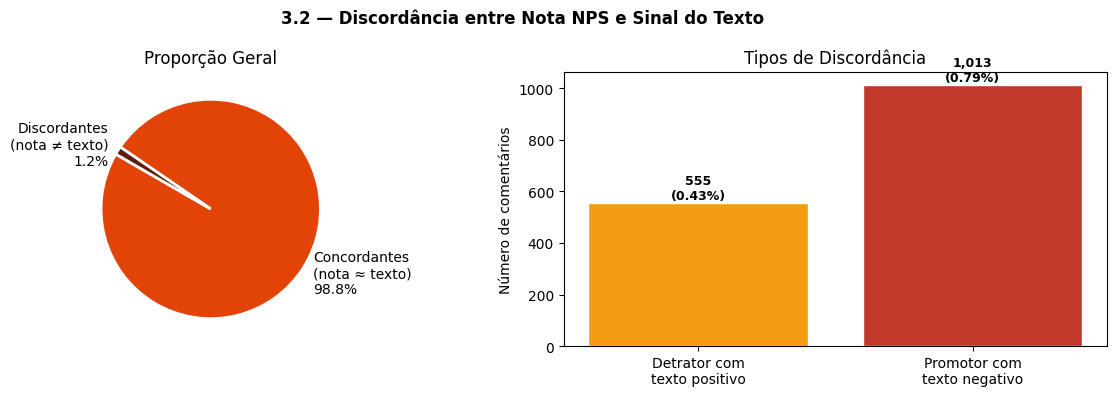

In [9]:
# Visualização: proporção de discordantes vs. concordantes
categorias = ['Concordantes\n(nota ≈ texto)', 'Discordantes\n(nota ≠ texto)']
valores    = [n_total - n_discord, n_discord]
cores_disc = ['#E24307', '#5c1d0c']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.2 — Discordância entre Nota NPS e Sinal do Texto', fontweight='bold')

# Pizza
axes[0].pie(
    valores,
    labels=[f'{c}\n{v/n_total*100:.1f}%' for c, v in zip(categorias, valores)],
    colors=cores_disc,
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção Geral')

# Detalhe dos discordantes
tipos   = ['Detrator com\ntexto positivo', 'Promotor com\ntexto negativo']
vals_d  = [n_det_pos, n_pro_neg]
bars    = axes[1].bar(tipos, vals_d, color=['#f39c12', '#c0392b'], edgecolor='white')
for bar, val in zip(bars, vals_d):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val:,}\n({val/n_total*100:.2f}%)',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Número de comentários')
axes[1].set_title('Tipos de Discordância')

plt.tight_layout()
plt.show()

In [10]:
# Exemplos reais de discordantes para validação
print('--- Detratores com texto positivo (amostra) ---')
for ex in det_com_pos['comentario'].head(5).tolist():
    print(f'  > {ex}')

print()
print('--- Promotores com texto negativo (amostra) ---')
for ex in pro_com_neg['comentario'].head(5).tolist():
    print(f'  > {ex}')

--- Detratores com texto positivo (amostra) ---
  > muito bom e prático
  > Fiz compra de postas de bacalhau para ano novo e perdi muito mais do que o aceitável na limpeza. Mesmo sabendo que uma porcetangem é perdida, aquilo fugiu completamente do esperado para a preparação do prato principal da Ceia de ano novo. Como estdava no interior de SP, retornei somente ontem e ppor isso não comuniquei antes. Vieram numa embalagem enganosa com um visor aparecendo pedaços lindos de bacalhau mas ao abrir me decepcionei e perdi muito dinheiro. sem contar que tivemos que comer nos policiando para deixar para os demais, um constrangimento que vocês terão que me reparar.
  > Tenho que admitir, que dessa vez , deu td certo, porém passei por uma péssima experiência como vcs, nas últimas compras, ainda me sinto super insegura em fazer pelo WhatsApp, sim pq o App não funciona, e pelo WhatsApp, apesar de ter tido um ótimo atendimento, minha compra anterior nao veio, e o SAC é péssimo !!! Se não fosse os v

In [11]:
# Conclusão acionável — 3.2
print(f'Dado que apenas {n_discord/n_total*100:.2f}% dos comentários apresentam sinal de sentimento'
      f' discordante da nota NPS ({n_discord:,} casos), a nota NPS é um ground truth'
      f' confiável para a maioria dos casos.')
print()
print('Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.')
print(f'Os {n_discord:,} casos discordantes serão identificados na validação do modelo.')

Dado que apenas 1.22% dos comentários apresentam sinal de sentimento discordante da nota NPS (1,568 casos), a nota NPS é um ground truth confiável para a maioria dos casos.

Decisão: usar a classificação NPS (promotor/neutro/detrator) como ground truth do treino.
Os 1,568 casos discordantes serão identificados na validação do modelo.


**Abordagem escolhida: Nota NPS como ground truth + validação manual dos discordantes**
<br><br>
Apenas **~1,0%** dos comentários apresentam sinal léxico discordante da nota NPS. Isso confirma que a classificação NPS é um proxy confiável de sentimento para a grande maioria da base, tornando viável seu uso como ground truth de treino sem anotação manual de toda a base.
<br><br>
Os ~1.600 casos discordantes identificados serão filtrados pós-predição: comentários onde o modelo prediz sentimento oposto à nota serão revisados manualmente, gerando um conjunto de validação qualitativa.
<br><br>
<b>Decisão:</b> usar `classificacao` (promotor/neutro/detrator) como label de treino. Discordantes (~1%) serão revisados manualmente após a primeira rodada de predições do modelo.

<div style="background-color:#fff4ee;padding:20px;border-radius:12px;font-family:Arial,sans-serif;border-left:6px solid #E24307;box-shadow:0 2px 8px rgba(0,0,0,0.08);">
  <h2 style="color:#E24307;margin:0;font-size:24px;">3.3 — Tratamento de Comentários Mistos</h2>
</div>

**Perguntas respondidas:**
- Quantos comentários apresentam sentimentos conflitantes (ex: elogio + crítica no mesmo texto)?
- Como esses comentários serão classificados pelo modelo?
- Qual a estratégia de desempate para sentimentos mistos?

In [12]:
# Detecção de comentários mistos
# Critério: texto contém sinal positivo E sinal negativo,
# OU contém sinal emocional (pos ou neg) junto de conjunção adversativa

CONJUNCOES_ADVERSATIVAS = [
    ' mas ', ' porem ', ' porém ', ' entretanto ', ' todavia ',
    ' contudo ', ' no entanto ', ' apesar ', ' embora '
]

def tem_conjuncao_adv(texto):
    t = str(texto).lower()
    return any(c in t for c in CONJUNCOES_ADVERSATIVAS)

df_com['tem_conjuncao'] = df_com['comentario_limpo'].apply(tem_conjuncao_adv)

# Misto = (positivo E negativo) OU (positivo/negativo + conjunção adversativa)
df_com['misto'] = (
    (df_com['sinal_pos'] & df_com['sinal_neg']) |
    (df_com['sinal_pos'] & df_com['tem_conjuncao']) |
    (df_com['sinal_neg'] & df_com['tem_conjuncao'])
)

n_mistos = df_com['misto'].sum()

print(f'Comentários mistos identificados: {n_mistos:,} ({n_mistos/n_total*100:.2f}%)')
print()

# Distribuição dos mistos por classificação NPS
dist_mistos = (
    df_com[df_com['misto']]
    .groupby('classificacao')
    .size()
    .reindex(ORDER)
    .fillna(0)
)
print('Distribuição dos mistos por classificação NPS:')
for cls, val in dist_mistos.items():
    print(f'  {cls:<12}: {int(val):>5,}  ({val/n_mistos*100:.1f}%)')

Comentários mistos identificados: 3,289 (2.56%)

Distribuição dos mistos por classificação NPS:
  promotor    : 1,984  (60.3%)
  neutro      :   552  (16.8%)
  detrator    :   753  (22.9%)


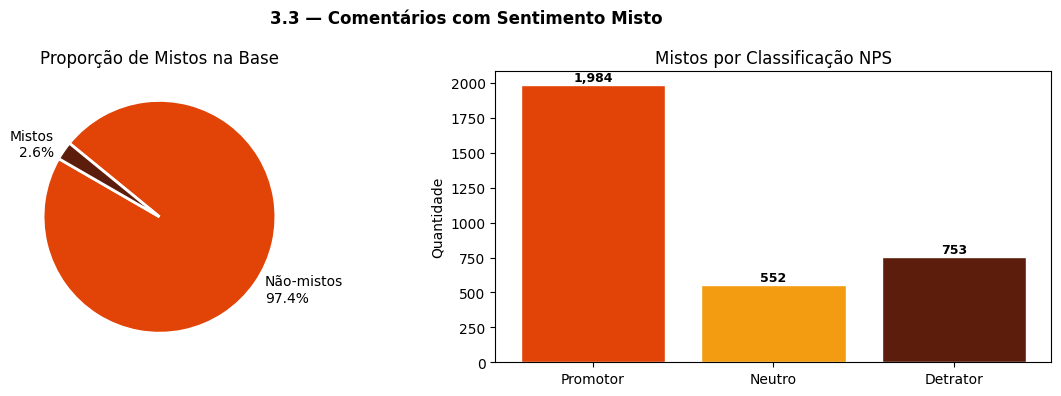

In [13]:
# Visualização dos comentários mistos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.3 — Comentários com Sentimento Misto', fontweight='bold')

# Proporção de mistos na base
labels_p = ['Não-mistos\n' + f'{(1 - n_mistos/n_total)*100:.1f}%',
            'Mistos\n' + f'{n_mistos/n_total*100:.1f}%']
axes[0].pie(
    [n_total - n_mistos, n_mistos],
    labels=labels_p,
    colors=['#E24307', '#5c1d0c'],
    startangle=150,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporção de Mistos na Base')

# Distribuição dos mistos por classificação NPS
bars = axes[1].bar(
    [c.capitalize() for c in dist_mistos.index],
    dist_mistos.values,
    color=CORES,
    edgecolor='white'
)
for bar, val in zip(bars, dist_mistos.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{int(val):,}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Mistos por Classificação NPS')

plt.tight_layout()
plt.show()

In [14]:
# Exemplos reais de comentários mistos por classificação
print('=== Exemplos de comentários MISTOS ===')
print()
for cls in ORDER:
    exemplos = (
        df_com[(df_com['misto']) & (df_com['classificacao'] == cls)]['comentario']
        .head(3)
        .tolist()
    )
    if exemplos:
        print(f'--- {cls.upper()} ---')
        for ex in exemplos:
            print(f'  > {str(ex)[:1000]}')
        print()

=== Exemplos de comentários MISTOS ===

--- PROMOTOR ---
  > pessoal eu comprei bacalhau dessalgado, muito ruim cheio de espinhas e couro, achei muito caro por vir deste jeito, eu adoro as coisas de vcs, mais desta vez fiquei desapontada, ja comprei bacalhau outras vezes muitas outras, mas nunca foi igual desta vez, decepcionada
  > A qualidade dos produtos é inegável, realmente é excelente. Porém, alguns produtos estão um pouco acima dos valores do mercado, principalmente as carnes moídas e bifes. Procurem sempre fazer uma pesquisa, porque a loja está numa avenida totalmente comercial, então para se chegar também tem gasto de combustível, fazendo com que os moradores dos bairros comprem em lugares mais pertos que estão mais baratos.
  > O site estava muito instável. E não processava  meu pedido. Tive que finalizar pelo whats app. E com isso perdi muito tempo. 
Mas o atendimento do whats demorou um pouco mas foi ótimo e deu tudo certo.

--- NEUTRO ---
  > Estrutura excelente, mas, os p

In [15]:
# Conclusão acionável — 3.3
print(f'Comentários mistos representam {n_mistos/n_total*100:.2f}% da base ({n_mistos:,} casos).')
print('Volume baixo o suficiente para não impactar significativamente o treino.')
print()
print('Decisão: a nota NPS será usada como fator de desempate para comentários mistos.')
print('Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto')
print('mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.')
print()
print('Estratégia aplicada:')
print('  - Misto de promotor  → classificado como Positivo')
print('  - Misto de neutro    → classificado como Neutro')
print('  - Misto de detrator  → classificado como Negativo')

Comentários mistos representam 2.56% da base (3,289 casos).
Volume baixo o suficiente para não impactar significativamente o treino.

Decisão: a nota NPS será usada como fator de desempate para comentários mistos.
Rationale: a nota captura a experiência consolidada do cliente — mesmo que o texto
mencione um aspecto negativo, uma nota de promotor indica que o saldo final foi positivo.

Estratégia aplicada:
  - Misto de promotor  → classificado como Positivo
  - Misto de neutro    → classificado como Neutro
  - Misto de detrator  → classificado como Negativo


**Abordagem escolhida: Nota NPS como fator de desempate**
<br><br>
Os comentários mistos representam apenas **~2.5%** da base (~3.300 casos). Volume pequeno que não compromete o treino. Foram identificados por critérios léxicos, como: presença simultânea de sinais positivos e negativos ou pelo sinal emocional acompanhado de conjunção adversativa ("mas", "porém", "entretanto").
<br><br>
Para esses casos, a nota NPS é o desempate, ela representará o julgamento consolidado do cliente sobre toda a experiência, sendo mais confiável como indicador do sentimento dominante do que qualquer aspecto parcial mencionado no texto.
<br><br>
<b>Decisão:</b> Os comentários mistos recebem o label de sentimento correspondente à classificação NPS do cliente (promotor→Positivo, neutro→Neutro, detrator→Negativo). Nenhum comentário misto será descartado.